# Dropout Simulation — ISS Barcode Deconvolution

Tests whether 2-gRNA pairs can be deconvolved from 4-color ISS signals when
individual sequencing positions fail (position-level dropout).

## Dropout Model
At each sequencing position p (out of L), with independent probability `dropout_p`,
the 4-channel base call is lost.  We know a read occurred at that cycle but not which
base was detected.  The masked position is treated as compatible with any predicted base.

## Two Analyses

**Part A — Monte Carlo dropout sweep:**
For each (L, dropout_p) pair, run 200 trials per gRNA pair and compute
average correct / ambiguous / failed rates.

**Part B — Positional dropout (deterministic):**
Exhaustively test all combinations of exactly n_drop positions being dropped.
Shows position-level information content and robustness to specific cycle failures.

---
All functions: `src/deconvolution.py`  |  Data: `data/ops_cloning.csv`

In [6]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt

from src.deconvolution import (
    load_spacers_from_csv,
    # core
    pair_sum, generate_imaging_matrix, all_pairs, deconvolution_counts,
    # dropout
    simulate_dropout, deconvolve_with_dropout,
    deconvolution_counts_dropout, deconvolution_counts_positional,
    # plots — deterministic
    plot_ambiguity_vs_L, plot_deconvolution_bars,
    # plots — dropout
    plot_dropout_ambiguity_vs_L, plot_dropout_accuracy_heatmap,
    plot_dropout_bars,
    # plots — positional
    plot_positional_dropout_bars, plot_n_drop_vs_accuracy,
    plot_positional_accuracy_heatmap,
)

# Reproducibility
SEED = 42
N_TRIALS = 200  # Monte Carlo trials per (pair, dropout_p, L)

# --- Load spacers ---
CSV_PATH = '../data/ops_cloning.csv'
spacers = load_spacers_from_csv(CSV_PATH, spacer_col='Guide with handles')
print(f'Loaded {len(spacers)} spacers')
print(f'First 3: {spacers[:3]}')
print(f'Total 2-gRNA pairs: {len(all_pairs(len(spacers)))}')

Loaded 52 spacers
First 3: ['GGTTCACGCGCAGATGCACGGTTTTAGAGCTAGAAATAG', 'GCGCTCGCGGATCAGCTCCTGTTTTAGAGCTAGAAATAG', 'GCGGTACCAGCGCGACTACGGTTTTAGAGCTAGAAATAG']
Total 2-gRNA pairs: 1378


## Deterministic Baseline (dropout_p = 0)

Reproduces the noiseless analysis from `combinatorial_deconvolution.ipynb`.
The dropout simulation at `dropout_p=0` must match these results exactly.

Noiseless baseline (exact lookup):
   L   correct   ambiguous   failed    strict   lenient
   5      1110         268        0   80.552%  100.000%
   8      1376           2        0   99.855%  100.000%
  10      1378           0        0  100.000%  100.000%
  15      1378           0        0  100.000%  100.000%
  20      1378           0        0  100.000%  100.000%


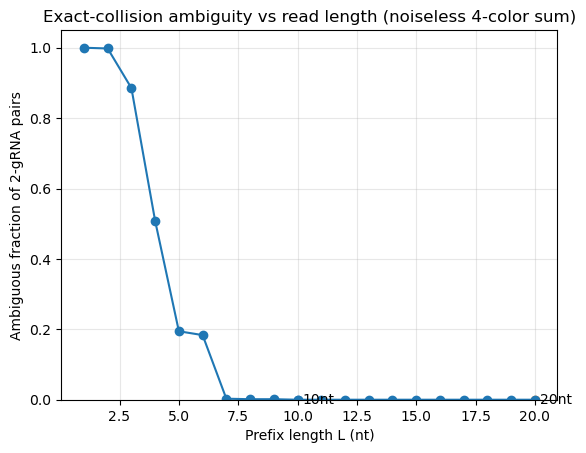

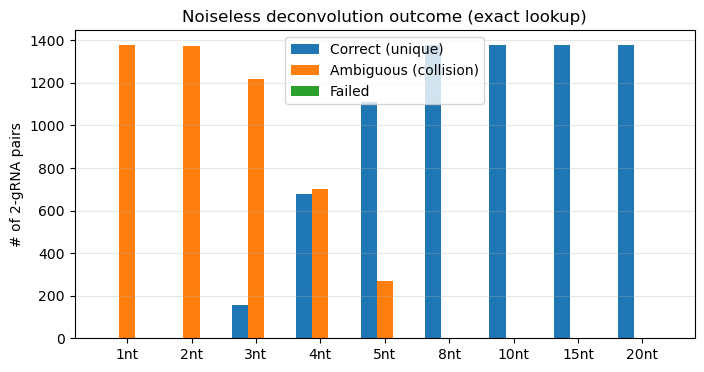

In [7]:
# Deterministic baseline: noiseless deconvolution
print('Noiseless baseline (exact lookup):')
print(f'{"L":>4}  {"correct":>8}  {"ambiguous":>10}  {"failed":>7}  {"strict":>8}  {"lenient":>8}')
for L in (5, 8, 10, 15, 20):
    r = deconvolution_counts(spacers, L)
    print(f"{L:>4}  {r['correct']:>8}  {r['ambiguous']:>10}  {r['failed']:>7}"
          f"  {r['accuracy_strict']:>8.3%}  {r['accuracy_lenient']:>8.3%}")

plot_ambiguity_vs_L(spacers, Ls=range(1, 21), mark=(10, 20))
plot_deconvolution_bars(spacers, Ls=(1, 2, 3, 4, 5, 8, 10, 15, 20))

## Part A — Monte Carlo Dropout Sweep

For each combination of prefix length L and dropout probability p, run N_TRIALS
Monte Carlo trials per pair.  Each trial independently drops each position with
probability p and attempts deconvolution using non-dropped positions only.

In [8]:
# Sweep parameters
DROPOUT_PS = [0.0, 0.05, 0.10, 0.20, 0.30, 0.50, 0.70]
Ls_sweep   = list(range(1, 21))

# Run full grid (this takes a few minutes)
print(f'Running {len(Ls_sweep)} × {len(DROPOUT_PS)} grid '
      f'({N_TRIALS} trials/pair × {len(all_pairs(len(spacers)))} pairs)...')
results_grid = {}
for L in Ls_sweep:
    for p in DROPOUT_PS:
        results_grid[(L, p)] = deconvolution_counts_dropout(
            spacers, L, p, n_trials=N_TRIALS, seed=SEED
        )
    print(f'  L={L:2d} done')
print('Grid complete.')

Running 20 × 7 grid (200 trials/pair × 1378 pairs)...
  L= 1 done
  L= 2 done
  L= 3 done
  L= 4 done
  L= 5 done
  L= 6 done
  L= 7 done


KeyboardInterrupt: 

In [ ]:
# Verify: dropout_p=0 matches noiseless baseline
print('Verification: dropout_p=0.0 vs noiseless exact lookup')
print(f'{"L":>4}  {"exact_strict":>14}  {"MC_strict":>10}  {"match":>6}')
for L in (5, 10, 15, 20):
    exact = deconvolution_counts(spacers, L)['accuracy_strict']
    mc    = results_grid[(L, 0.0)]['accuracy_strict']
    print(f'{L:>4}  {exact:>14.4%}  {mc:>10.4%}  {abs(exact-mc)<1e-6!s:>6}')

In [ ]:
# A1: Ambiguity fraction vs L — one line per dropout_p
plot_dropout_ambiguity_vs_L(
    spacers, Ls=Ls_sweep, dropout_ps=DROPOUT_PS,
    n_trials=N_TRIALS, seed=SEED,
    output_path='../outputs/dropout_ambiguity_vs_L.png'
)

In [ ]:
# A2: Accuracy heatmap — L × dropout_p (strict accuracy)
plot_dropout_accuracy_heatmap(
    results_grid, Ls=Ls_sweep, dropout_ps=DROPOUT_PS,
    metric='accuracy_strict',
    output_path='../outputs/dropout_heatmap_strict.png'
)

# A3: Accuracy heatmap — lenient accuracy
plot_dropout_accuracy_heatmap(
    results_grid, Ls=Ls_sweep, dropout_ps=DROPOUT_PS,
    metric='accuracy_lenient',
    output_path='../outputs/dropout_heatmap_lenient.png'
)

In [ ]:
# A4: Deconvolution bars at L=10 for all dropout levels
plot_dropout_bars(
    spacers, L=10, dropout_ps=DROPOUT_PS,
    n_trials=N_TRIALS, seed=SEED,
    output_path='../outputs/dropout_bars_L10.png'
)

# A5: Deconvolution bars at L=20
plot_dropout_bars(
    spacers, L=20, dropout_ps=DROPOUT_PS,
    n_trials=N_TRIALS, seed=SEED,
    output_path='../outputs/dropout_bars_L20.png'
)

## Part B — Positional Dropout (Deterministic)

Exhaustively test all C(L, n_drop) combinations of exactly n_drop dropped positions.
Answers: "which positions are most informative?" and "how does accuracy degrade as
more positions fail?"

- `n_drop=1`: single-position failure — which cycle is most critical?
- `n_drop=2,3,...`: multi-position failure — how many cycles can fail?

In [9]:
# B1: Single-position dropout at L=10 and L=20
print('Computing single-position dropout (n_drop=1)...')
pos_res_L10 = deconvolution_counts_positional(spacers, L=10, n_drop=1)
pos_res_L20 = deconvolution_counts_positional(spacers, L=20, n_drop=1)
print('Done.')

print(f'\nL=10 single-position dropout:')
print(f'  Min accuracy: {min(v["accuracy_strict"] for v in pos_res_L10.values()):.3%}')
print(f'  Max accuracy: {max(v["accuracy_strict"] for v in pos_res_L10.values()):.3%}')

print(f'\nL=20 single-position dropout:')
print(f'  Min accuracy: {min(v["accuracy_strict"] for v in pos_res_L20.values()):.3%}')
print(f'  Max accuracy: {max(v["accuracy_strict"] for v in pos_res_L20.values()):.3%}')

Computing single-position dropout (n_drop=1)...
Done.

L=10 single-position dropout:
  Min accuracy: 99.855%
  Max accuracy: 100.000%

L=20 single-position dropout:
  Min accuracy: 100.000%
  Max accuracy: 100.000%


In [10]:
# B2: Per-position accuracy bars at L=10
plot_positional_dropout_bars(
    pos_res_L10, L=10, n_drop=1,
    output_path='../outputs/positional_dropout_bars_L10.png'
)

# B3: Per-position accuracy bars at L=20
plot_positional_dropout_bars(
    pos_res_L20, L=20, n_drop=1,
    output_path='../outputs/positional_dropout_bars_L20.png'
)

Saved: ../outputs/positional_dropout_bars_L10.png
Saved: ../outputs/positional_dropout_bars_L20.png


In [11]:
# B4: Positional accuracy heatmap across multiple L values
plot_positional_accuracy_heatmap(
    spacers, Ls=[5, 6, 7, 8, 9, 10, 12, 15, 20],
    metric='accuracy_strict',
    output_path='../outputs/positional_accuracy_heatmap.png'
)

Saved: ../outputs/positional_accuracy_heatmap.png


In [12]:
# B5: n_drop sweep at L=10 (n_drop = 1, 2, 3)
print('Computing multi-position dropout at L=10 (n_drop=1,2,3)...')
plot_n_drop_vs_accuracy(
    spacers, L=10, n_drops=[1, 2, 3],
    metric='accuracy_strict',
    output_path='../outputs/n_drop_vs_accuracy_L10.png'
)
print('Done.')

Computing multi-position dropout at L=10 (n_drop=1,2,3)...
Saved: ../outputs/n_drop_vs_accuracy_L10.png
Done.


In [ ]:
# B6: n_drop sweep at L=20 (n_drop = 1, 2, 3, 4, 5)
print('Computing multi-position dropout at L=20 (n_drop=1..5)...')
plot_n_drop_vs_accuracy(
    spacers, L=20, n_drops=[1, 2, 3, 4, 5],
    metric='accuracy_strict',
    output_path='../outputs/n_drop_vs_accuracy_L20.png'
)
print('Done.')

Computing multi-position dropout at L=20 (n_drop=1..5)...


In [ ]:
# B7: Distribution of accuracy over all 2-drop combos at L=10
pos_res_L10_2drop = deconvolution_counts_positional(spacers, L=10, n_drop=2)
plot_positional_dropout_bars(
    pos_res_L10_2drop, L=10, n_drop=2,
    output_path='../outputs/positional_dropout_hist_L10_2drop.png'
)

## Summary

Results saved to `outputs/`.  Key metrics to check:

- `dropout_heatmap_strict.png`: overall accuracy landscape across (L, dropout_p)
- `n_drop_vs_accuracy_L10.png` / `_L20.png`: how many cycles can fail per readout
- `positional_accuracy_heatmap.png`: which positions are most critical
- `dropout_bars_L10.png` / `_L20.png`: breakdown (correct/ambiguous/failed) by dropout level

**Verification checks:**
1. `dropout_p=0.0` in Part A matches noiseless baseline (see verification cell above)
2. `dropout_p=1.0` would make every pair maximally ambiguous (all pairs are candidates)
3. `n_drop=0` (no dropout) trivially gives 100% accuracy on all pairs